In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
method = 'ls'
ord = 8
nb_samples = [i for i in range(25, 325, 25)]
basis = 'total-order'
with open(f'timings_{method}_{ord}_{basis}.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

In [4]:
avg_std_dict = {}
for key in loaded_dict[0].keys():
    for subdict in loaded_dict:
        if key not in avg_std_dict:
            avg_std_dict[key] = []
        avg_std_dict[key].append([np.mean(subdict[key]), np.std(subdict[key])])

In [5]:
avg_std_dict.keys()

dict_keys(['training_samples', 'model_set', 'coefficients', 'evaluation', 'full'])

In [35]:
from visualization import *
avg_std_dict_compressed = {}
avg_std_dict_compressed['offline']= []
avg_std_dict_compressed['evaluation'] = []
avg_std_dict_compressed['full'] = []
for subdict in loaded_dict:
    subdict['offline'] = np.zeros_like(subdict['training_samples'])
    for key in loaded_dict[0].keys():
        if key not in ['evaluation', 'full']:
            subdict['offline'] += subdict[key]
    for key in avg_std_dict_compressed.keys():
        field = np.array(subdict[key])
        mu = get_mu(field[None,:], field.shape[0])[0]
        print(np.array(mu)[None])
        sigma = get_sig(field[None,:], np.array(mu)[None], field.shape[0])[0]
        print(sigma)
        
        avg_std_dict_compressed[key].append(np.array([mu,sigma]))
for key in avg_std_dict_compressed.keys():
    avg_std_dict_compressed[key] = np.array(avg_std_dict_compressed[key])
    
    

[-1.36831856]
0.8519829084093224
[-3.65462482]
0.056109755968099834
[-3.76951975]
0.08699503132725973
[-1.46590785]
0.18271973136373007
[-3.73116157]
0.09862152571492361
[-3.77207673]
0.04161956009635602
[-1.39475505]
0.015837624110535253
[-3.77731885]
0.0023513792214928516
[-3.80223668]
0.02484794455067253
[-1.29331949]
0.013045978852983354
[-3.77822813]
0.00700338916691237
[-3.7833203]
0.01220845724136964
[-1.15377032]
0.1295739006630495
[-3.77920997]
0.005892150902024316
[-3.7769632]
0.004805478183390597
[-1.13639322]
0.0022099032336398467
[-3.77043112]
0.011832616793454176
[-3.77591898]
0.009926457784348057
[-1.07262925]
0.006415506716397354
[-3.77772129]
0.006190865915733635
[-3.78941456]
0.021288082392358982
[-0.98987458]
0.09551419576874776
[-3.74267209]
0.005205699987021878
[-3.75685755]
0.011919277957400689
[-0.98801617]
0.0067195533156668985
[-3.77188392]
0.03258983806117473
[-3.79999809]
0.032029140594983414
[-0.95243547]
0.001375784576145851
[-3.73980479]
0.0034250615484898

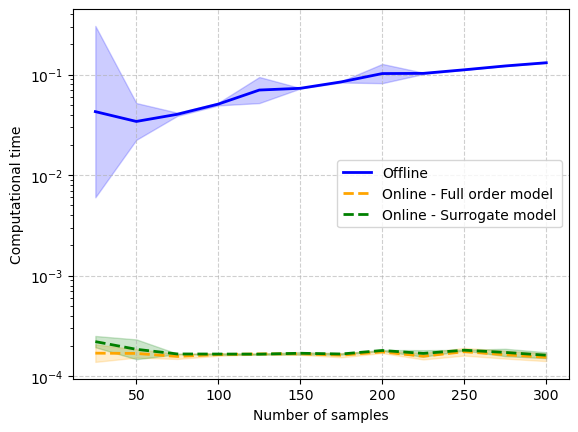

In [36]:

x = nb_samples

avg = avg_std_dict_compressed['offline'][:,0]
std = avg_std_dict_compressed['offline'][:,1]
plt.plot(x, 10**avg, color='blue', label='Offline', linewidth=2)
plt.fill_between(x, 10**(avg - std), 10**(avg + std), color='blue', alpha=0.2)

avg_full = avg_std_dict_compressed['full'][:,0]
std_full = avg_std_dict_compressed['full'][:,1]

plt.plot(x, 10**avg_full, color='orange', linestyle='--', label='Online - Full order model', linewidth=2)
plt.fill_between(x, 10**(avg_full - std_full), 10**(avg_full + std_full), color='orange', alpha=0.2)

avg_evaluation = avg_std_dict_compressed['evaluation'][:,0]
std_evaluation = avg_std_dict_compressed['evaluation'][:,1]

plt.plot(x, 10**avg_evaluation, color='green', linestyle='--', label='Online - Surrogate model', linewidth=2)
plt.fill_between(x, 10**(avg_evaluation - std_evaluation), 10**(avg_evaluation + std_evaluation), color='green', alpha=0.2)


plt.xlabel('Number of samples')
plt.ylabel('Computational time')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show or save the plot

plt.savefig('prova_timings_ls_static.pdf')

In [37]:
avg_std_dict_compressed2 = {}
avg_std_dict_compressed2['training_samples']= []
avg_std_dict_compressed2['coefficients'] = []
avg_std_dict_compressed2['evaluation'] = []
avg_std_dict_compressed2['full'] = []
for subdict in loaded_dict:
    subdict['offline'] = np.zeros_like(subdict['training_samples'])
    for key in loaded_dict[0].keys():
        if key not in ['evaluation', 'full', 'training_samples']:
            subdict['offline'] += subdict[key]
    for key in avg_std_dict_compressed2.keys():
        avg_std_dict_compressed2[key].append([np.mean(subdict[key]), np.std(subdict[key])])
for key in avg_std_dict_compressed2.keys():
    avg_std_dict_compressed2[key] = np.array(avg_std_dict_compressed2[key])
    
    

In [38]:
k_list = []
for i, m in enumerate(nb_samples):
    print('Numerator',(m* avg_std_dict_compressed2['full'][i,0] - avg_std_dict_compressed2['coefficients'][i,0]))
    print('Denominator',(avg_std_dict_compressed2['full'][i,0] - avg_std_dict_compressed2['evaluation'][i,0]))
    k_list.append((m* avg_std_dict_compressed2['full'][i,0] - avg_std_dict_compressed2['coefficients'][i,0])/(avg_std_dict_compressed2['full'][i,0] - avg_std_dict_compressed2['evaluation'][i,0]))

Numerator -0.11714191436767578
Denominator -5.0067901611328125e-05
Numerator -0.0006879329681396488
Denominator -2.031326293945311e-05
Numerator 0.0011704921722412113
Denominator -9.107589721679671e-06
Numerator 0.003447914123535156
Denominator -1.9073486328125e-06
Numerator -0.000231838226318358
Denominator 8.583068847656304e-07
Numerator 0.006968116760253905
Denominator -2.1457672119140625e-06
Numerator 0.007516527175903318
Denominator -4.291534423828125e-06
Numerator 0.007514286041259765
Denominator -5.769729614257823e-06
Numerator 0.011753463745117189
Denominator -1.0633468627929666e-05
Numerator 0.018627738952636717
Denominator -5.7220458984375e-06
Numerator 0.017922592163085938
Denominator -8.630752563476573e-06
Numerator 0.017484426498413086
Denominator -7.295608520507818e-06


Text(0, 0.5, 'Minimum optimal threshold $k$')

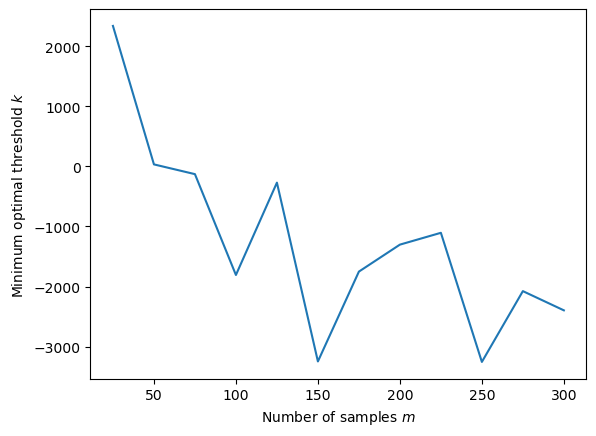

In [39]:

plt.plot(nb_samples, k_list)
plt.xlabel(r'Number of samples $m$')
plt.ylabel(r'Minimum optimal threshold $k$')
